In [1]:
import sys
sys.path.append("../..")
from src.point_process import *

import json

In [2]:
with open('../../parameters/superposition-f-02.json', 'r') as file:
    params = json.load(file)

In [3]:
W = params['thomas_1']['W']
w, h = W
lam_p1, lam_p2 = params['thomas_1']['lam_p'], params['thomas_2']['lam_p']
nu1, nu2 = params['thomas_1']['nu'], params['thomas_2']['nu']
sig1, sig2 = params['thomas_1']['sig'], params['thomas_2']['sig']

In [4]:
thomas_process1 = ThomasProcess(lam_p1, nu1, sig1)
parents1, points_thomas1 = thomas_process1.generate(W, seed=46)
thomas_process2 = ThomasProcess(lam_p2, nu2, sig2)
parents2, points_thomas2 = thomas_process2.generate(W, seed=46)
points_sup = np.concatenate([points_thomas1, points_thomas2])

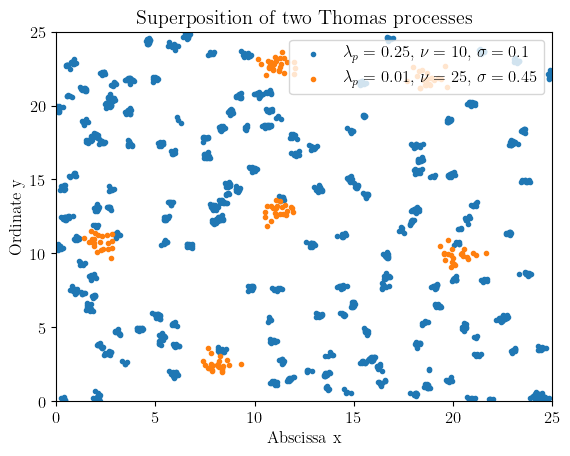

In [5]:
display_superposition([points_thomas1, points_thomas2], 
                      window=W, 
                      title="Superposition of two Thomas processes", 
                      labels=[fr'$\lambda_p = {lam_p1}$, $\nu = {nu1}$, $\sigma = {sig1}$', 
                              fr'$\lambda_p = {lam_p2}$, $\nu = {nu2}$, $\sigma = {sig2}$'])

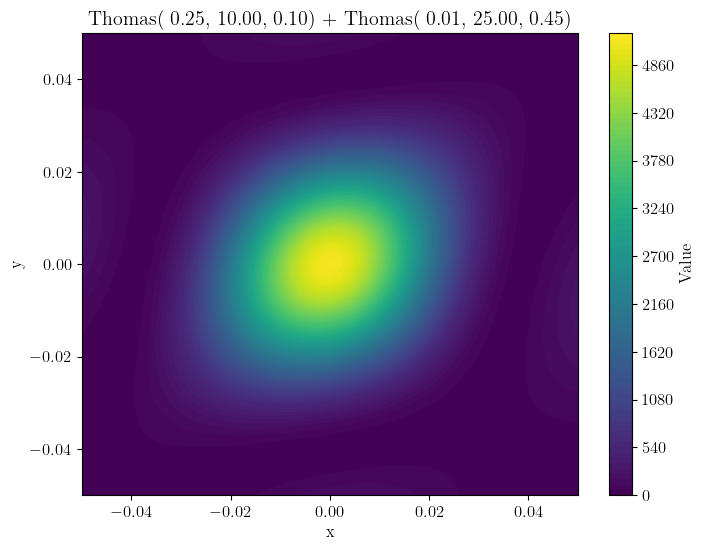

In [6]:
plt.rcParams.update({
    "text.usetex": True,          # Use LaTeX to render text
    "font.family": "serif",       # Match LaTeX serif font
    "font.size": 12
    })

area=w*h
lambda_hat=len(points_sup)/area

x=np.arange(-0.05,0.051,0.002)
y=np.arange(-0.05,0.051,0.002)
X,Y= np.meshgrid(x,y)

Z=periodogram(X,Y,lambda_hat,points_sup,area)

plt.figure(figsize=(8,6))
plt.contourf(X,Y,Z,100, cmap='viridis')
plt.colorbar(label='Value')
plt.title(f'Thomas({lam_p1: .2}, {nu1: .2f}, {sig1: .2f}) + Thomas({lam_p2: .2}, {nu2: .2f}, {sig2: .2f})')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig('../../img/bartlett-1.eps', format='eps')
plt.show()